# Time Series — ARIMA / SARIMA / SARIMAX

Notebook **Wiki + Tutoriel + Cheat-sheet** sur la **famille ARIMA** — la pierre angulaire du forecasting statistique depuis 1970, toujours utilisée en 2026 comme **baseline solide** et pour les séries courtes (50–200 points) où les modèles de deep learning sur-apprennent.

Ce qu'on couvre :

1. Les variantes **AR / MA / ARMA / ARIMA / SARIMA / SARIMAX** et leurs équations.
2. La **méthodologie Box-Jenkins** (identification → estimation → diagnostic → forecast).
3. Tests de stationnarité (**ADF + KPSS**) et décomposition saisonnière.
4. Lecture **ACF / PACF** pour proposer les ordres.
5. **AutoARIMA** moderne : `pmdarima` et `statsforecast` (Nixtla).
6. **Diagnostic des résidus** (bruit blanc ou pattern manqué).
7. **SARIMAX** avec variables exogènes.
8. Pièges classiques et alternatives 2026 (foundation models).

Dataset : **Air Passengers** (mensuel 1949-1960), mutualisé avec `TS_Time_Series_Intro` et `TS_Time_Series_Overview`.

## 1. La famille ARIMA

**Notation générale** : `SARIMA(p, d, q)(P, D, Q, s)` (+ `X` pour exogène).

- **AR(p)** — *AutoRegressive* : la valeur dépend de ses propres passés.

$$y_t = c + \varphi_1 y_{t-1} + \dots + \varphi_p y_{t-p} + \varepsilon_t$$

- **MA(q)** — *Moving Average* : la valeur dépend des erreurs passées.

$$y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}$$

- **ARMA(p, q)** = AR(p) + MA(q), pour une série **déjà stationnaire**.
- **I(d)** — *Integrated* : on différencie `d` fois ($\nabla y_t = y_t - y_{t-1}$) pour stationnariser.
- **ARIMA(p, d, q)** = ARMA appliqué à la série différenciée `d` fois.
- **SARIMA(p,d,q)(P,D,Q,s)** : ajoute une composante saisonnière de période `s` (différenciation saisonnière $\nabla_s y_t = y_t - y_{t-s}$ et termes AR/MA saisonniers).
- **SARIMAX** : SARIMA + régresseurs externes (`exog`).

| Cas | Notation |
|---|---|
| Série stationnaire | ARIMA(p, 0, q) |
| Tendance, sans saison | ARIMA(p, 1, q) |
| Saisonnier mensuel | SARIMA(p, d, q)(P, D, Q, 12) |
| Avec covariables | SARIMAX(p, d, q, exog=X) |

**Hypothèses** : stationnarité après différenciation, bruit $\varepsilon_t$ blanc gaussien, linéarité.

**Forces** : interprétable, intervalles de prédiction propres, peu de données nécessaires.
**Faiblesses** : mauvais sur le non-linéaire, un modèle par série (pas de partage entre séries), covariables limitées.

## 2. Méthodologie Box-Jenkins

La démarche classique (Box & Jenkins, 1970) en 4 temps :

1. **Identification** — visualiser, tester la stationnarité (ADF/KPSS), différencier au besoin, lire ACF/PACF pour proposer `(p, q)` et `(P, Q)`.
2. **Estimation** — ajuster les coefficients par maximum de vraisemblance.
3. **Diagnostic** — les résidus sont-ils du **bruit blanc** ? Sinon, un pattern a été oublié.
4. **Forecast** — prévoir avec intervalles de confiance.

En 2026, on remplace souvent les étapes 1–2 par un **AutoARIMA** qui parcourt l'espace des ordres et garde le meilleur (AIC/BIC). Comprendre la méthode reste indispensable pour **interpréter et diagnostiquer**.

## 3. Dataset : Air Passengers

Série mensuelle du nombre de passagers aériens (1949–1960, 144 points). C'est le cas d'école de SARIMA : **tendance croissante** + **saisonnalité annuelle** dont l'**amplitude croît avec le niveau** (saisonnalité *multiplicative*). On charge la série depuis statsmodels (offline, déterministe) et on réserve les **12 derniers mois** pour le test.

Série : 144 obs  | Train : 132  | Test : 12


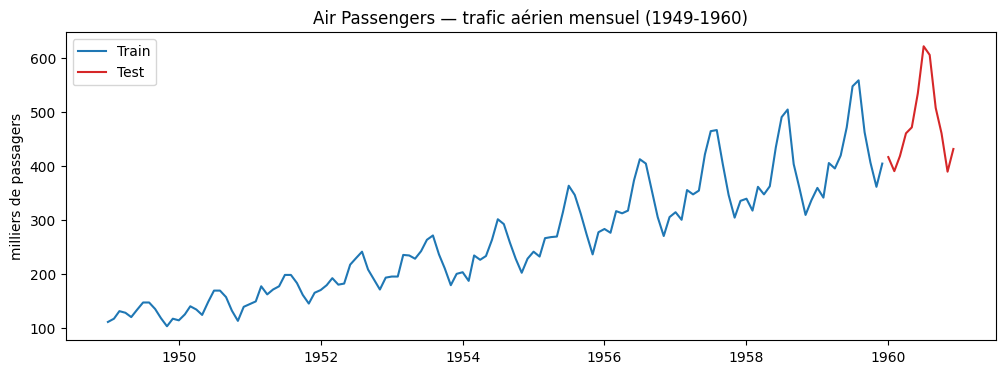

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
import warnings

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)


def load_air_passengers() -> pd.Series:
    """Charge Air Passengers (mensuel, 1949-1960) avec un DatetimeIndex propre.

    Source offline et déterministe : R dataset `AirPassengers` empaqueté dans
    statsmodels. Retourne une Series indexée par début de mois (freq='MS').
    """
    raw = get_rdataset("AirPassengers", "datasets").data
    s = pd.Series(
        raw["value"].to_numpy(dtype=float),
        index=pd.date_range("1949-01-01", periods=len(raw), freq="MS"),
        name="passengers",
    )
    return s


ts = load_air_passengers()
train, test = ts.iloc[:-12], ts.iloc[-12:]   # 12 derniers mois en test
print(f"Série : {len(ts)} obs  | Train : {len(train)}  | Test : {len(test)}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train.index, train.values, label="Train")
ax.plot(test.index, test.values, label="Test", color="C3")
ax.set_title("Air Passengers — trafic aérien mensuel (1949-1960)")
ax.set_ylabel("milliers de passagers")
ax.legend()
plt.show()

On voit nettement la **tendance haussière** et des **pics annuels** dont l'amplitude grandit avec le niveau. Cette amplitude croissante est le signe d'une saisonnalité multiplicative → un `log` stabilisera la variance avant modélisation.

## 4. Tester la stationnarité

ARIMA suppose une série **stationnaire** (moyenne et variance constantes). On combine deux tests aux hypothèses **inverses**, ce qui rend le verdict robuste :

- **ADF** (Augmented Dickey-Fuller) — $H_0$ : racine unitaire ⇒ *non* stationnaire. On veut **p < 0.05**.
- **KPSS** — $H_0$ : série *stationnaire*. On veut **p > 0.05**.

Conclusion ferme de stationnarité quand **ADF < 0.05 ET KPSS > 0.05**. Pour Air Passengers on applique `log` (variance) puis `diff(1)` (tendance) puis `diff(12)` (saison). La **décomposition saisonnière** confirme visuellement les trois composantes.

Série brute :
  ADF  brute                  stat=  0.888  p=0.9929  → non-stationnaire
  KPSS brute                  stat=  1.886  p=0.0100  → NON stationnaire
Après log + diff(1) + diff(12) :
  ADF  log+diff1+diff12       stat= -4.087  p=0.0010  → STATIONNAIRE
  KPSS log+diff1+diff12       stat=  0.051  p=0.1000  → stationnaire


/tmp/ipykernel_2183735/1441961618.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, *_ = kpss(s.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_2183735/1441961618.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, *_ = kpss(s.dropna(), regression="c", nlags="auto")


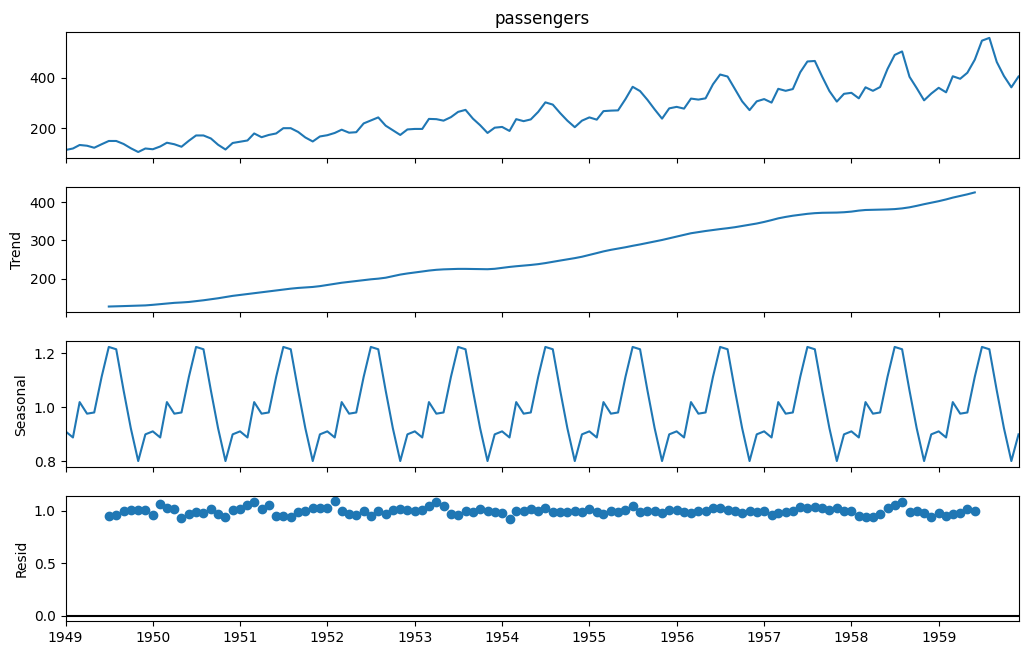

In [2]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose


def adf_test(s: pd.Series, name: str = "") -> float:
    """Test ADF (H0 : racine unitaire → NON stationnaire). Retourne la p-value.

    p < 0.05 ⇒ on rejette H0 ⇒ série stationnaire.
    """
    stat, pval, *_ = adfuller(s.dropna())
    verdict = "STATIONNAIRE" if pval < 0.05 else "non-stationnaire"
    print(f"  ADF  {name:<22} stat={stat:7.3f}  p={pval:.4f}  → {verdict}")
    return pval


def kpss_test(s: pd.Series, name: str = "") -> float:
    """Test KPSS (H0 : série STATIONNAIRE — hypothèse inverse de l'ADF).

    p < 0.05 ⇒ on rejette la stationnarité. ADF et KPSS sont complémentaires :
    on veut ADF<0.05 ET KPSS>0.05 pour conclure à la stationnarité.
    """
    stat, pval, *_ = kpss(s.dropna(), regression="c", nlags="auto")
    verdict = "stationnaire" if pval > 0.05 else "NON stationnaire"
    print(f"  KPSS {name:<22} stat={stat:7.3f}  p={pval:.4f}  → {verdict}")
    return pval


print("Série brute :")
adf_test(train, "brute"); kpss_test(train, "brute")

log_diff = np.log(train).diff().diff(12)
print("Après log + diff(1) + diff(12) :")
adf_test(log_diff, "log+diff1+diff12"); kpss_test(log_diff, "log+diff1+diff12")

decomp = seasonal_decompose(train, model="multiplicative", period=12)
fig = decomp.plot()
fig.set_size_inches(11, 7)
plt.show()

La série **brute** est non stationnaire (ADF p≈0.99, KPSS rejette). Après `log + diff(1) + diff(12)`, **les deux tests concordent** sur la stationnarité (ADF p≈0.001, KPSS p>0.05) → on retient `d=1, D=1`. La décomposition isole bien tendance, saison annuelle et résidu.

## 5. Identification des ordres (ACF / PACF)

Sur la série **stationnarisée**, les corrélogrammes suggèrent les ordres :

| Pattern ACF | Pattern PACF | Modèle |
|---|---|---|
| Décroissance lente | Coupure nette à lag p | **AR(p)** |
| Coupure nette à lag q | Décroissance lente | **MA(q)** |
| Décroissance lente | Décroissance lente | **ARMA(p, q)** |
| Pics aux lags multiples de s | idem | composantes **saisonnières** (P, Q) |

Règle pratique : la **PACF** coupe après le lag `p` (→ AR), l'**ACF** coupe après le lag `q` (→ MA). Une décroissance lente persistante signale un besoin de différenciation supplémentaire (attention au sur-différenciage).

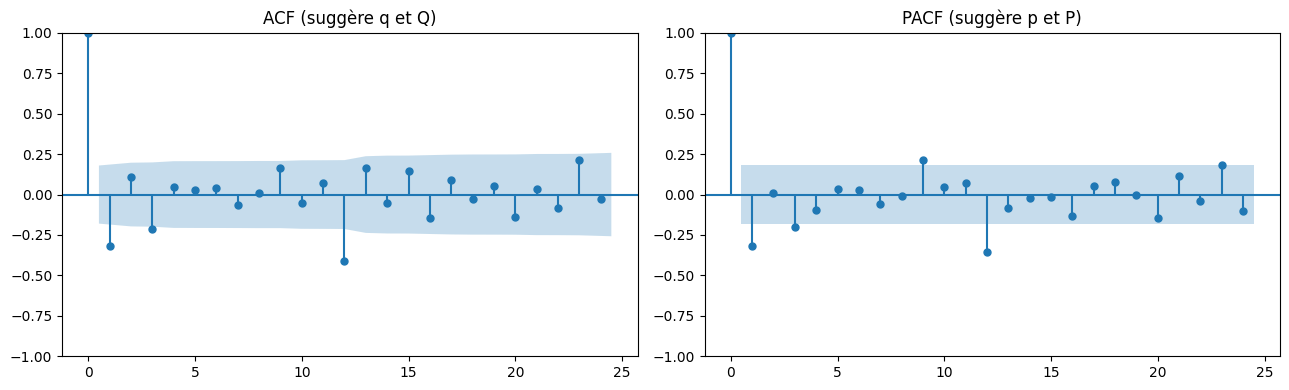

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ts_stat = log_diff.dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(ts_stat, lags=24, ax=axes[0])
axes[0].set_title("ACF (suggère q et Q)")
plot_pacf(ts_stat, lags=24, ax=axes[1])
axes[1].set_title("PACF (suggère p et P)")
fig.tight_layout()
plt.show()

On lit des pics significatifs aux premiers lags et autour du lag saisonnier 12 — cohérent avec de petits ordres `(p, q)` et `(P, Q)`. Plutôt que de trancher à l'œil, on délègue la sélection fine à un AutoARIMA.

## 6. AutoARIMA

Au lieu de fixer `(p, d, q, P, D, Q)` à la main, un AutoARIMA parcourt l'espace des ordres et garde celui qui minimise un critère d'information (AIC/BIC). Deux implémentations de référence en 2026 :

- **`pmdarima.auto_arima`** — classique, bâti sur statsmodels, recherche stepwise (pmdarima 2.1.1, toujours maintenu).
- **`statsforecast.AutoARIMA`** (Nixtla) — réécriture **compilée Numba**, beaucoup plus rapide et capable de scaler à des milliers de séries en parallèle. À privilégier dès qu'on a du volume.

On fixe `d=1, D=1` (déduits des tests de stationnarité) et on laisse l'algorithme choisir le reste.

In [4]:
import pmdarima as pm

auto = pm.auto_arima(
    train, seasonal=True, m=12,
    start_p=0, max_p=3, start_q=0, max_q=3,
    start_P=0, max_P=2, start_Q=0, max_Q=2,
    d=1, D=1, information_criterion="aic",
    stepwise=True, suppress_warnings=True, error_action="ignore",
)
AUTO_ORDER = auto.order
AUTO_SEAS = auto.seasonal_order
print(f"pmdarima → order={AUTO_ORDER}  seasonal_order={AUTO_SEAS}  AIC={auto.aic():.2f}")

pmdarima → order=(1, 1, 0)  seasonal_order=(0, 1, 0, 12)  AIC=899.90


On confronte ce résultat à **statsforecast**, qui attend un *long format* (`unique_id`, `ds`, `y`). On récupère l'ordre interne et le MAPE sur le test.

In [5]:
from sklearn.metrics import mean_absolute_percentage_error
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA as SFAutoARIMA

sf_df = pd.DataFrame({
    "unique_id": "airline",
    "ds": train.index,
    "y": train.values,
})
sf = StatsForecast(models=[SFAutoARIMA(season_length=12)], freq="MS")
sf.fit(sf_df)
try:
    arma = sf.fitted_[0, 0].model_["arma"]  # (p, q, P, Q, m, d, D)
    print(f"statsforecast → arma(p,q,P,Q,m,d,D)={arma}")
except Exception as e:
    print(f"statsforecast → ordre interne non extrait ({e})")

fc_sf = sf.predict(h=12)["AutoARIMA"].to_numpy()
mape_sf = mean_absolute_percentage_error(test.values, fc_sf)
print(f"statsforecast AutoARIMA — MAPE test : {mape_sf:.3%}")

statsforecast → arma(p,q,P,Q,m,d,D)=(1, 0, 0, 0, 12, 1, 1)
statsforecast AutoARIMA — MAPE test : 4.180%


Les deux moteurs convergent vers un modèle très proche (ordres simples + différenciations `d=1, D=1`). On retient les ordres de `pmdarima` (`AUTO_ORDER`, `AUTO_SEAS`) pour la suite, afin d'inspecter le détail du modèle avec statsmodels.

## 7. Estimation SARIMA et prévision

On ajuste un `SARIMAX` avec les ordres trouvés (pas codés en dur : on réutilise `AUTO_ORDER`/`AUTO_SEAS`). `enforce_stationarity=False` / `enforce_invertibility=False` relâchent les contraintes quand l'optimiseur peine à converger. On évalue **hors échantillon** (sur le test) avec RMSE, MAE et MAPE.

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

sarima = SARIMAX(
    train, order=AUTO_ORDER, seasonal_order=AUTO_SEAS,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)
print(sarima.summary().tables[1])

fc = sarima.get_forecast(steps=len(test))
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int(alpha=0.05)

print(f"\nRMSE : {root_mean_squared_error(test, fc_mean):.2f}")
print(f"MAE  : {mean_absolute_error(test, fc_mean):.2f}")
print(f"MAPE : {mean_absolute_percentage_error(test, fc_mean):.3%}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2448      0.091     -2.699      0.007      -0.423      -0.067
sigma2       109.5980     13.496      8.121      0.000      83.146     136.050

RMSE : 23.92
MAE  : 18.52
MAPE : 4.180%


Un MAPE de l'ordre de **4 %** sur 12 mois prédits est excellent pour un modèle aussi parcimonieux — c'est tout l'intérêt d'ARIMA comme baseline. On visualise maintenant la prévision et son incertitude.

## 8. Forecast + intervalles de confiance

On superpose train, test réel et prévision, avec la **bande d'incertitude à 95 %**. Point clé : l'intervalle **s'élargit avec l'horizon** — l'incertitude s'accumule, ce qui rappelle qu'ARIMA n'est pas fiable pour les prévisions très lointaines.

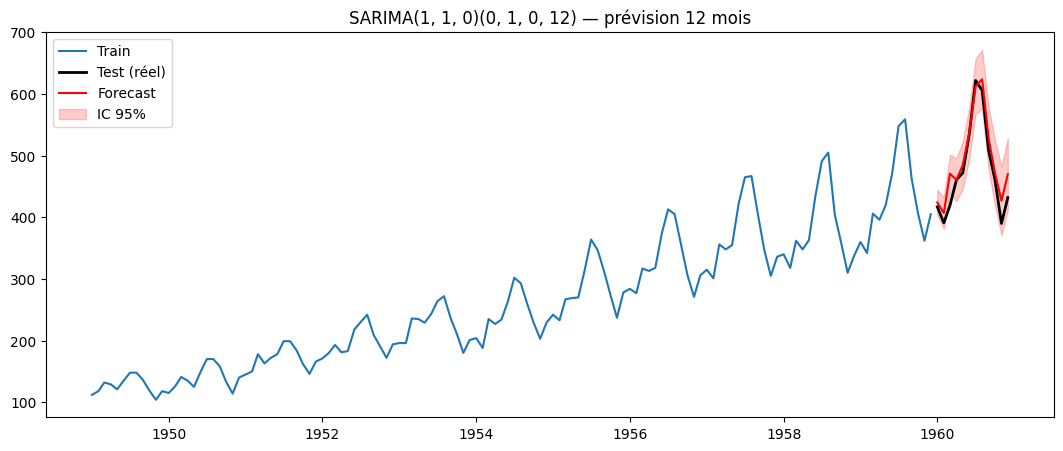

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train.values, label="Train")
ax.plot(test.index, test.values, label="Test (réel)", color="black", linewidth=2)
ax.plot(fc_mean.index, fc_mean.values, label="Forecast", color="red")
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                color="red", alpha=0.2, label="IC 95%")
ax.set_title(f"SARIMA{AUTO_ORDER}{AUTO_SEAS} — prévision 12 mois")
ax.legend()
plt.show()

La prévision suit bien la tendance et la saisonnalité du test, qui reste dans la bande à 95 %. Reste à vérifier que le modèle n'a pas laissé d'information dans les résidus.

## 9. Diagnostic des résidus

Un bon modèle ARIMA laisse des résidus = **bruit blanc** :

- centrés sur 0, variance constante ;
- **sans autocorrélation** → test de **Ljung-Box** ($H_0$ : pas d'autocorrélation, on veut **p > 0.05**) ;
- approximativement **normaux** → histogramme + **Q-Q plot**.

S'ils ne le sont pas, un pattern a été manqué → revoir `(p, d, q)` / `(P, D, Q, s)`. Le diagnostic visuel se fait aussi en une ligne via `sarima.plot_diagnostics()`.

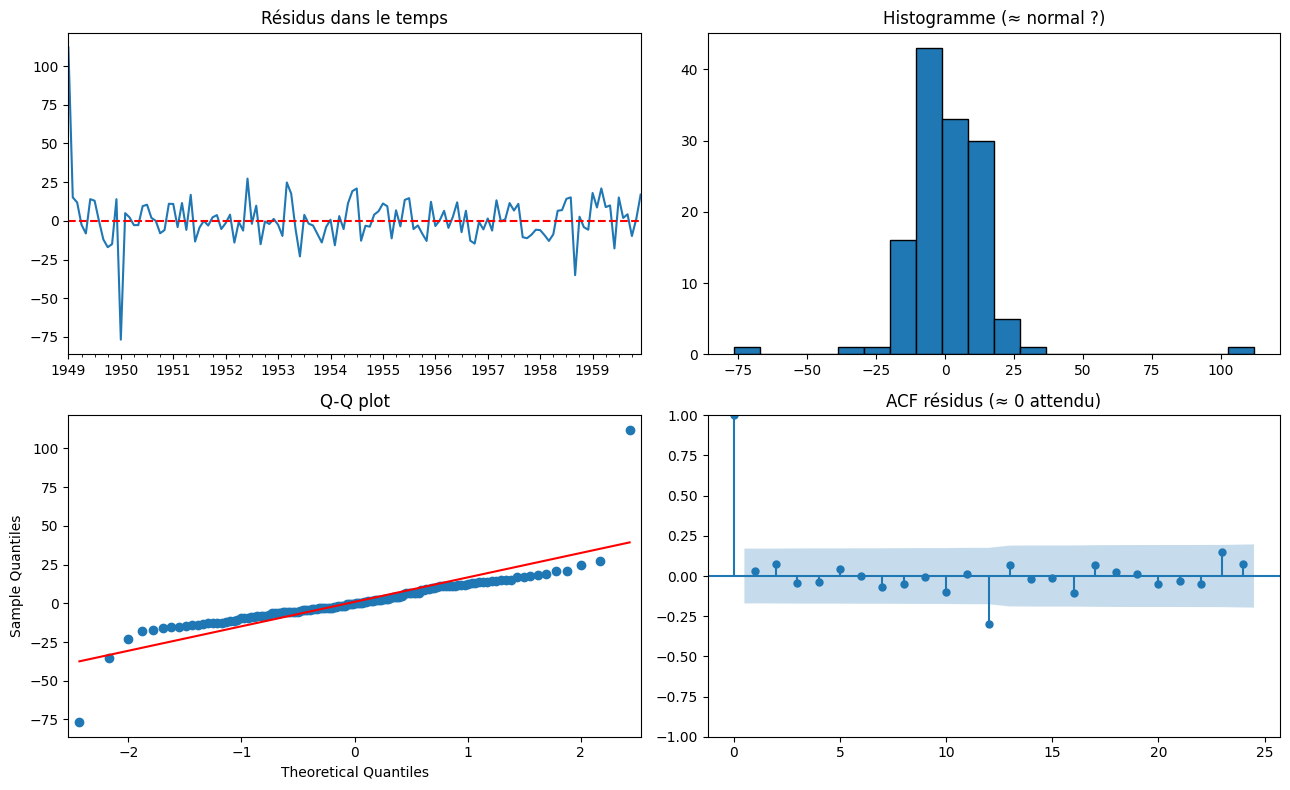

Ljung-Box (H0 : pas d'autocorrélation résiduelle) :
      lb_stat  lb_pvalue
12  16.935364   0.152045
24  25.555930   0.376075
p > 0.05 sur les lags ⇒ résidus ≈ bruit blanc ⇒ modèle OK


In [8]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot

residuals = sarima.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
residuals.plot(ax=axes[0, 0], title="Résidus dans le temps")
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 1].hist(residuals, bins=20, edgecolor="k")
axes[0, 1].set_title("Histogramme (≈ normal ?)")
qqplot(residuals, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q plot")
plot_acf(residuals, lags=24, ax=axes[1, 1])
axes[1, 1].set_title("ACF résidus (≈ 0 attendu)")
fig.tight_layout()
plt.show()

lb = acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
print("Ljung-Box (H0 : pas d'autocorrélation résiduelle) :")
print(lb)
print("p > 0.05 sur les lags ⇒ résidus ≈ bruit blanc ⇒ modèle OK")

Ljung-Box donne **p > 0.05** aux lags 12 et 24 : pas d'autocorrélation résiduelle significative, les résidus se comportent comme du bruit blanc → le modèle est validé.

## 10. SARIMAX — variables exogènes

Quand on dispose de **covariables** (prix, météo, événements marketing), on les passe via `exog`. Deux conditions pour qu'elles aident vraiment :

1. **Lien causal réel** avec la cible (sinon zéro gain, voire du bruit).
2. **Connues sur l'horizon** de prévision (sinon il faut un second modèle pour les prédire → bruit ajouté).

Ci-dessous une exogène **jouet** (campagne 1 mois sur 6, sans lien causal) : elle illustre l'API mais, comme attendu, **n'améliore pas** le RMSE.

In [9]:
# Exogène jouet : campagne marketing 1 mois sur 6. Pour un VRAI gain, l'exogène
# doit (a) avoir un lien causal réel avec y et (b) être connu sur l'horizon.
exog_train = pd.DataFrame(
    {"marketing": (np.arange(len(train)) % 6 == 0).astype(float)}, index=train.index)
exog_test = pd.DataFrame(
    {"marketing": (np.arange(len(train), len(train) + len(test)) % 6 == 0).astype(float)},
    index=test.index)

arimax = SARIMAX(
    train, exog=exog_train, order=AUTO_ORDER, seasonal_order=AUTO_SEAS,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)
fc_x = arimax.get_forecast(steps=len(test), exog=exog_test).predicted_mean

print(f"SARIMAX (exog jouet) — RMSE : {root_mean_squared_error(test, fc_x):.2f}")
print(f"SARIMA  (sans exog)  — RMSE : {root_mean_squared_error(test, fc_mean):.2f}")

SARIMAX (exog jouet) — RMSE : 23.92
SARIMA  (sans exog)  — RMSE : 23.92


RMSE identique avec et sans l'exogène : c'est la leçon à retenir — **une covariable sans lien causal n'apporte rien**. L'intérêt de SARIMAX n'apparaît qu'avec des régresseurs réellement explicatifs et disponibles sur le futur.

## 11. Pièges et anti-patterns

| ❌ Anti-pattern | ✅ Correctif |
|---|---|
| Choisir `(p, d, q)` au hasard | Workflow Box-Jenkins : ADF/KPSS + ACF/PACF + diagnostic |
| Sur-différencier (`d > 2` sans raison) | Le sur-différenciage injecte du bruit ; différencier juste assez |
| Ignorer la saisonnalité visible | Passer en **SARIMA** (composantes P, D, Q, s) |
| Ne pas vérifier les résidus | Bruit blanc obligatoire (Ljung-Box) pour valider |
| Trop de paramètres (`p+q` grand) | Overfit ; AIC/BIC favorise la parcimonie |
| `enforce_stationarity=True` quand ça ne converge pas | Mettre `False` (contraintes relâchées) |
| Comparer les modèles via le RMSE **sur train** | Toujours évaluer **hors échantillon** (test) |
| Prévoir trop loin | L'incertitude explose — limiter l'horizon |
| Exogène sans lien causal | Inutile, voire nuisible (cf. §10) |
| Variance croissante non traitée | Stabiliser par `log` avant de modéliser |

## 12. Au-delà d'ARIMA (2026)

ARIMA reste une excellente baseline, mais d'autres approches le dépassent selon le contexte :

- **Saisonnalités multiples** (jour + semaine + an) → Prophet, TBATS, ou deep learning.
- **N séries similaires** → modèles **globaux** (un seul modèle pour toutes les séries, ML/gradient boosting sur features).
- **Non-linéarités, ruptures de régime** → modèles state-space, ML.
- **Foundation models pré-entraînés (zero-shot)**, la grande nouveauté 2024-2026 :
  - **TimesFM 2.5** (Google) — décodeur, contexte long, quantiles.
  - **Chronos-2** (Amazon) — zero-shot SOTA, bat souvent les modèles statistiques *tunés*, supporte désormais les covariables.
  - **Moirai-2** (Salesforce) — covariables natives, fréquences variées.
  - **TimeGPT** (Nixtla) — propriétaire, API.

Ces modèles transforment la prévision d'un *problème d'entraînement* en *problème de sélection de modèle*. Pour une série courte et bien structurée comme Air Passengers, ARIMA reste néanmoins difficile à battre en rapport simplicité/précision.

## 13. Sources

- [Box & Jenkins — méthode Box-Jenkins](https://en.wikipedia.org/wiki/Box%E2%80%93Jenkins_method)
- [statsmodels — SARIMAX](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)
- [pmdarima — auto_arima](https://alkaline-ml.com/pmdarima/)
- [Nixtla statsforecast — AutoARIMA](https://nixtlaverse.nixtla.io/statsforecast/docs/models/autoarima.html)
- [Hyndman & Athanasopoulos — FPP3, chapitre ARIMA](https://otexts.com/fpp3/arima.html)
- [FPP (Pythonic Way) — foundation models](https://otexts.com/fpppy/15-foundation-models.html)
- Notebooks liés : `TS_Time_Series_Intro` (bases), `TS_Time_Series_Overview` (panorama 2026).